In [10]:
import pandas as pd

In [11]:
file_path = 'Titanic.csv'
def read_file(file_path):
    return pd.read_csv(file_path).head()
read_file(file_path)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [63]:
df = pd.read_csv('Titanic.csv')
cols = ['PassengerId','Name','Ticket']
df.drop(cols, axis= 1, inplace= True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [ ]:
from config import COLS_DROP
from preprocessing import drop_cols
drop_cols(df,COLS_DROP)

KeyError: "['PassengerId', 'Name', 'Ticket'] not found in axis"

In [61]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [64]:
dtypes = df.dtypes
nunique = df.nunique()
pd.DataFrame({"dtypes":dtypes, "nunique": nunique }).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
dtypes,int64,int64,str,float64,int64,int64,float64,str,str
nunique,2,3,2,88,7,7,248,147,3


In [65]:
cat_cols= ["Survived","Pclass","Sex","SibSp","Parch","Embarked"]
df[cat_cols] = df[cat_cols].astype("category")


In [66]:
def get_type_Info(df):
    return pd.DataFrame({"dtypes":df.dtypes, "nunique": df.nunique() }).T

In [67]:
get_type_Info(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
dtypes,category,category,category,float64,category,category,float64,str,category
nunique,2,3,2,88,7,7,248,147,3


In [68]:
df.select_dtypes("category")

,Survived,Pclass,Sex,SibSp,Parch,Embarked
0,0,3,male,1,0,S
1,1,1,female,1,0,C
2,1,3,female,0,0,S
3,1,1,female,1,0,S
4,0,3,male,0,0,S
...,...,...,...,...,...,...
886,0,2,male,0,0,S
887,1,1,female,0,0,S
888,0,3,female,1,2,S
889,1,1,male,0,0,C


In [69]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    category
 1   Pclass    891 non-null    category
 2   Sex       891 non-null    category
 3   Age       714 non-null    float64 
 4   SibSp     891 non-null    category
 5   Parch     891 non-null    category
 6   Fare      891 non-null    float64 
 7   Cabin     204 non-null    str     
 8   Embarked  889 non-null    category
dtypes: category(6), float64(2), str(1)
memory usage: 26.7 KB


In [75]:
null = df.isnull().sum()
ratio = (null / 891)*100
ratio

Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age          0.000000
SibSp        0.000000
Parch        0.000000
Fare         0.000000
Cabin       77.104377
Embarked     0.000000
dtype: float64

In [103]:
df = df.dropna(subset=['Embarked'])

In [102]:
# df.describe()
median = df['Age'].median()
df['Age']  = df['Age'].fillna(median, inplace=True)

C:\Users\Smart\AppData\Local\Temp\ipykernel_12832\143703380.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age']  = df['Age'].fillna(median, inplace=True)


In [101]:
null = df.isnull().sum()
ratio = (null / 891)*100
pd.DataFrame({"null":null, "ratio": ratio }).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,578.000000,0.0
ratio,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64.870932,0.0


In [ ]:
col_name = df.select_dtypes("number").columns
for col in col_name:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1
    lower_fence = q1 - 1.5*IQR
    upper_fence = q3 + 1.5*IQR
    #print(lower_fence,upper_fence)
    lower_outliers = df[df[col]< lower_fence][col].values
    upper_outliers = df[df[col]> upper_fence][col].values
    print(lower_outliers)
    print("="*20)
    print(upper_outliers)
    df[col].replace(lower_outliers,lower_fence)
    
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,1))
for i , col in enumerate(col_name):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col],orient='h')
    plt.title(f"{col} Boxplot")
plt.show()

NameError: name 'df' is not defined

In [19]:
df.describe()

,Age,Fare
count,889.000000,889.000000
mean,29.315152,32.096681
std,12.984932,49.697504
min,0.420000,0.000000
25%,22.000000,7.895800
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,1))
for i , col in enumerate(col_name):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col],orient='h')
    plt.title(f"{col} Boxplot")
plt.show()

NameError: name 'col_name' is not defined

<Figure size 1000x100 with 0 Axes>

In [104]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
885    False
887    False
888    False
889    False
890    False
Length: 779, dtype: bool

In [100]:
df.drop_duplicates(inplace=True)

In [81]:
df.duplicated().sum()

np.int64(0)

In [34]:
def remove_duplicate(df,subset_cols,keep_strategy = "first"):
    return (df.drop_duplicates(subset=subset_cols,keep=keep_strategy).reset_index(drop=True))

In [82]:
num_col = df.select_dtypes("number").columns


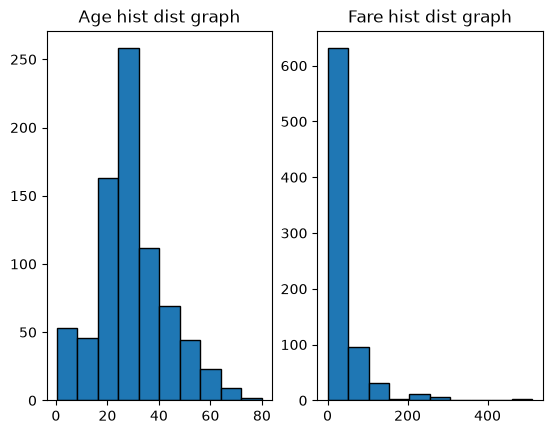

In [87]:
plt.Figure(figsize=(9,2))
for i , col in enumerate(num_col):
    plt.subplot(1,2,i+1)
    plt.hist(df[col],edgecolor = "black")
    plt.title(f"{col} hist dist graph")
    
plt.show()


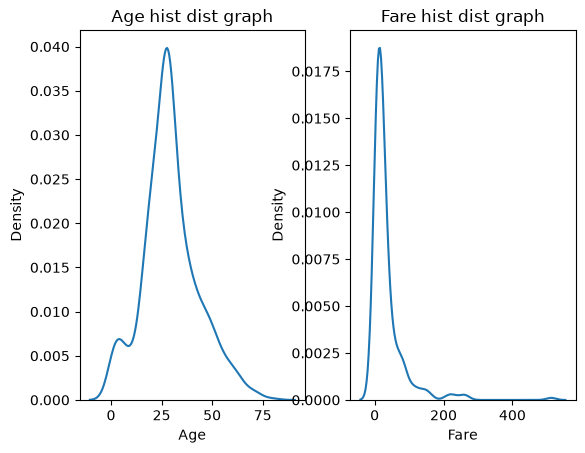

In [105]:
plt.Figure(figsize=(9,2))
for i , col in enumerate(num_col):
    plt.subplot(1,2,i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} hist dist graph")
    
plt.show()


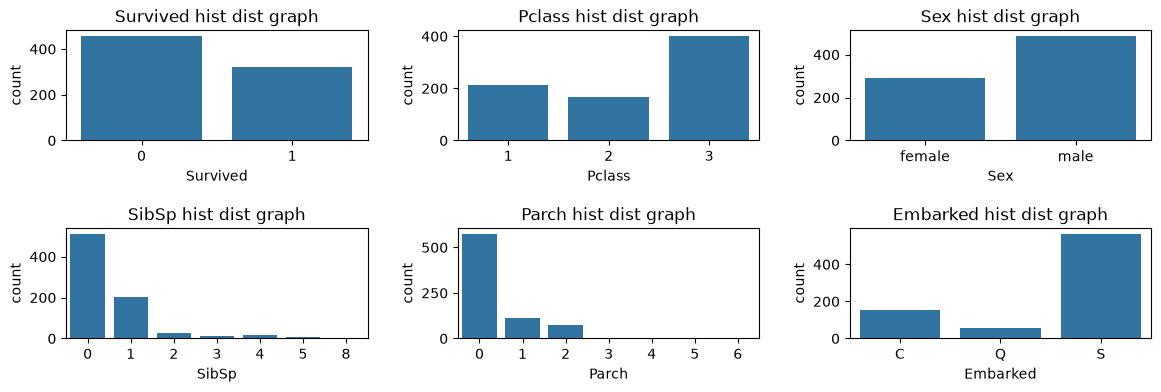

In [98]:
cat_col = df.select_dtypes("category").columns
plt.figure(figsize=(14,4))
for i , col in enumerate(cat_col):
    plt.subplot(2,3,i+1)
    sns.countplot(x=col,data=df)
    plt.title(f"{col} hist dist graph")
    
plt.subplots_adjust(hspace=0.8,wspace=0.3)

In [107]:
unique = df['Survived'].value_counts()
count = unique.values
catigories = unique.index
catigories

CategoricalIndex([0, 1], categories=[0, 1], ordered=False, dtype='category', name='Survived')

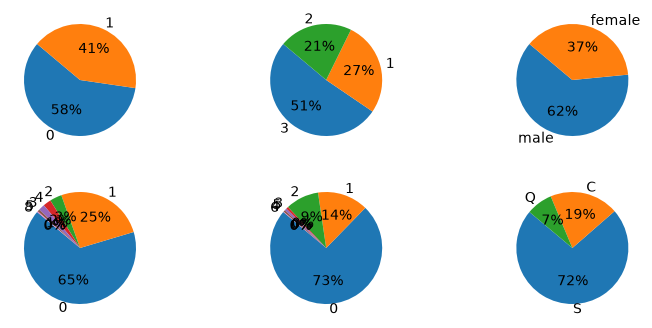

In [114]:
plt.figure(figsize=(9,4))
for i , col in enumerate(cat_col):
    plt.subplot(2,3,i+1)
    unique = df[col].value_counts()
    count = unique.values
    catigories = unique.index
    plt.pie(count,labels=catigories,autopct="%1.1d%%",startangle=140)

Text(0, 0.5, 'fare')

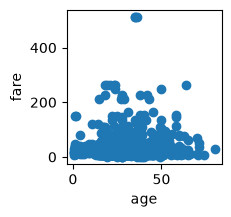

In [117]:
plt.figure(figsize=(2,2))
plt.scatter(df['Age'],df["Fare"])
plt.xlabel("age")
plt.ylabel("fare")


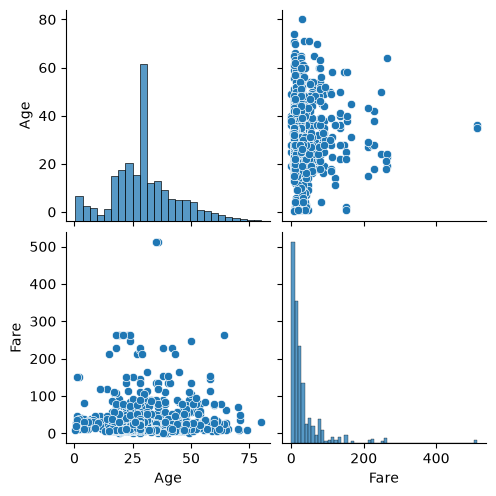

In [118]:
sns.pairplot(df)

<Axes: >

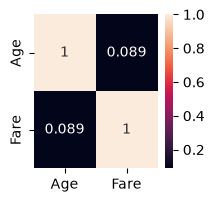

In [122]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(2,2))
sns.heatmap(corr,annot=True)